# Week 3 — Priority Prediction with XGBoost & RF Comparison

**Project:** AI-Powered Task Management System
**Prepared by:** Vijayasiva

**Goals**
1. Build the priority feature matrix with the **same recipe as notebook 06** (shared TF-IDF + `days_to_deadline`, `estimated_hours`, `story_points` + one-hot `category`) on the shared stratified split, and save it to `models/` for reuse
2. Tune **XGBoost** with GridSearchCV (`n_estimators`, `max_depth`, `learning_rate`, `subsample`)
3. Evaluate with accuracy, macro precision/recall/F1 and a confusion matrix
4. Produce the combined **Random Forest vs. XGBoost** comparison on the current shared artifacts and recommend the final priority model for Week 4

> Note: notebook 06's committed outputs were produced against pre-update local artifacts, so its Random Forest is **re-fit here with notebook 06's tuned hyperparameters** on the current shared features to keep the comparison apples-to-apples.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
RANDOM_STATE = 42
MODELS = "../models"

df = pd.read_csv("../data/processed/tasks_nlp.csv")
train_idx = joblib.load(f"{MODELS}/train_idx.joblib")
test_idx = joblib.load(f"{MODELS}/test_idx.joblib")
tfidf_train = joblib.load(f"{MODELS}/tfidf_train.joblib")
tfidf_test = joblib.load(f"{MODELS}/tfidf_test.joblib")
tfidf_names = joblib.load(f"{MODELS}/tfidf_vectorizer.joblib").get_feature_names_out()
print(f"Rows: {len(df)} | TF-IDF: {tfidf_train.shape} / {tfidf_test.shape}")

Rows: 8000 | TF-IDF: (6400, 1814) / (1600, 1814)


## 1. Priority Feature Matrix (same recipe as notebook 06)

In [2]:
NUMERIC_COLS = ["days_to_deadline", "estimated_hours", "story_points"]
TARGET = "priority"
CLASS_ORDER = ["Low", "Medium", "High", "Critical"]

df_train, df_test = df.loc[train_idx], df.loc[test_idx]
y_train_lbl = df_train[TARGET].to_numpy()
y_test_lbl = df_test[TARGET].to_numpy()

cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
cat_train = cat_encoder.fit_transform(df_train[["category"]])
cat_test = cat_encoder.transform(df_test[["category"]])

num_train = csr_matrix(df_train[NUMERIC_COLS].to_numpy(dtype=float))
num_test = csr_matrix(df_test[NUMERIC_COLS].to_numpy(dtype=float))

X_train = hstack([tfidf_train, num_train, cat_train]).tocsr()
X_test = hstack([tfidf_test, num_test, cat_test]).tocsr()
feature_names = np.concatenate([
    [f"tfidf__{t}" for t in tfidf_names],
    NUMERIC_COLS,
    cat_encoder.get_feature_names_out(["category"]),
])
print(f"X_train {X_train.shape} | X_test {X_test.shape} | features {len(feature_names)}")

# XGBoost needs integer labels; use the natural priority order
label_map = {c: i for i, c in enumerate(CLASS_ORDER)}
y_train = np.array([label_map[v] for v in y_train_lbl])
y_test = np.array([label_map[v] for v in y_test_lbl])
pd.Series(y_train_lbl).value_counts().reindex(CLASS_ORDER)

X_train (6400, 1824) | X_test (1600, 1824) | features 1824


Low         2101
Medium      2043
High        1187
Critical    1069
Name: count, dtype: int64

In [3]:
# Save the assembled matrices so notebook 06 (and Week 4) can reuse them directly
joblib.dump(X_train, f"{MODELS}/priority_X_train.joblib")
joblib.dump(X_test, f"{MODELS}/priority_X_test.joblib")
joblib.dump(list(feature_names), f"{MODELS}/priority_feature_names.joblib")
joblib.dump(cat_encoder, f"{MODELS}/priority_category_encoder.joblib")
print("Saved priority feature matrices, feature names and category encoder to models/")

Saved priority feature matrices, feature names and category encoder to models/


## 2. XGBoost — GridSearchCV Tuning

In [4]:
param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.3],
    "subsample": [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb = XGBClassifier(
    objective="multi:softprob", num_class=4, tree_method="hist",
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss",
)
grid_xgb = GridSearchCV(xgb, param_grid, scoring="f1_macro", cv=cv, verbose=1)
grid_xgb.fit(X_train, y_train)
print("Best params:", grid_xgb.best_params_)
print(f"Best CV macro-F1: {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}
Best CV macro-F1: 0.6454


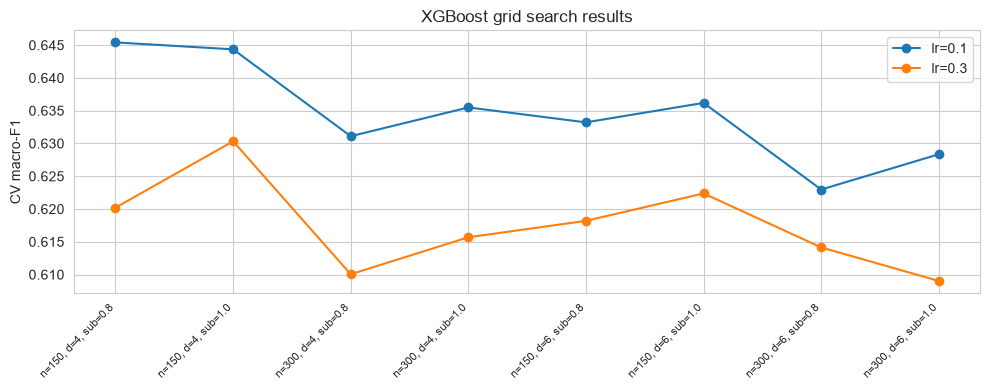

In [5]:
# Tuning curve: CV macro-F1 across the grid, grouped by learning rate
res = pd.DataFrame(grid_xgb.cv_results_)
res["setting"] = res.apply(lambda r: f"n={r['param_n_estimators']}, d={r['param_max_depth']}, sub={r['param_subsample']}", axis=1)
plt.figure(figsize=(10, 4))
for lr, g in res.groupby("param_learning_rate"):
    plt.plot(g["setting"], g["mean_test_score"], marker="o", label=f"lr={lr}")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.ylabel("CV macro-F1")
plt.title("XGBoost grid search results")
plt.legend()
plt.tight_layout()
plt.show()

## 3. XGBoost — Test-Set Evaluation

In [6]:
best_xgb = grid_xgb.best_estimator_
pred_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)
rep_xgb = classification_report(y_test, pred_xgb, target_names=CLASS_ORDER,
                                output_dict=True, zero_division=0)
print(f"Test accuracy: {acc_xgb:.4f}\n")
print(classification_report(y_test, pred_xgb, target_names=CLASS_ORDER, zero_division=0))

Test accuracy: 0.6306

              precision    recall  f1-score   support

         Low       0.66      0.76      0.71       494
      Medium       0.54      0.52      0.53       529
        High       0.54      0.44      0.49       306
    Critical       0.85      0.82      0.83       271

    accuracy                           0.63      1600
   macro avg       0.64      0.64      0.64      1600
weighted avg       0.63      0.63      0.63      1600



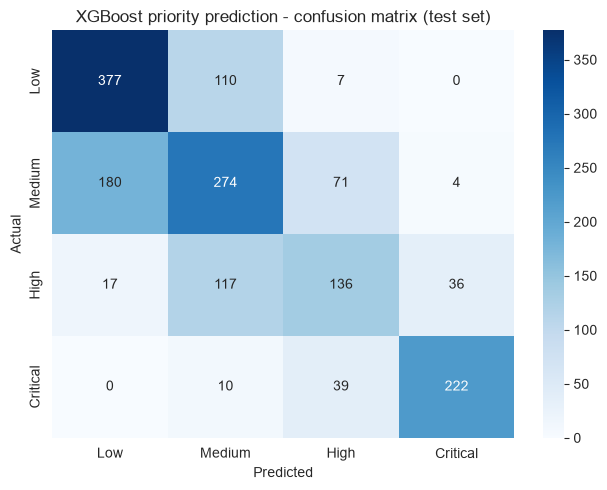

In [7]:
cm = confusion_matrix(y_test, pred_xgb)
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("XGBoost priority prediction - confusion matrix (test set)")
plt.tight_layout()
plt.show()

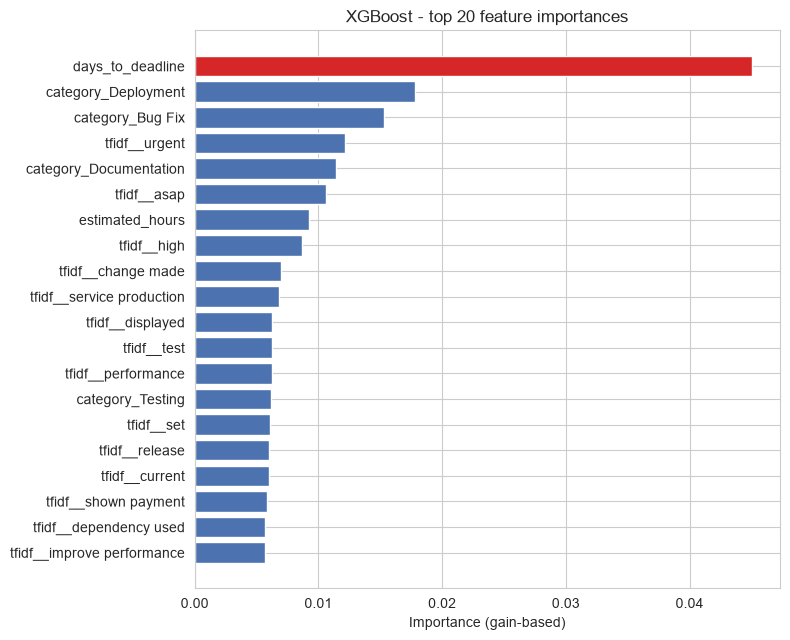

Top 5:
days_to_deadline          0.045055
category_Deployment       0.017844
category_Bug Fix          0.015308
tfidf__urgent             0.012174
category_Documentation    0.011423


In [8]:
imp = pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values(ascending=False)
top = imp.head(20).iloc[::-1]
colors = ["#d62728" if f == "days_to_deadline" else "#4c72b0" for f in top.index]
plt.figure(figsize=(8, 6.5))
plt.barh(top.index, top.values, color=colors)
plt.xlabel("Importance (gain-based)")
plt.title("XGBoost - top 20 feature importances")
plt.tight_layout()
plt.show()
print("Top 5:")
print(imp.head(5).to_string())

## 4. Random Forest on the Same Features

Re-fit with **notebook 06's tuned hyperparameters** (`n_estimators=100`, `max_depth=None`, `min_samples_leaf=4`, `class_weight=None`) on the current shared artifacts, so both models are compared on identical features and split.

In [9]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, min_samples_leaf=4,
                            class_weight=None, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
rep_rf = classification_report(y_test, pred_rf, target_names=CLASS_ORDER,
                               output_dict=True, zero_division=0)
print(f"Test accuracy: {acc_rf:.4f}")
print(classification_report(y_test, pred_rf, target_names=CLASS_ORDER, zero_division=0))

Test accuracy: 0.5587
              precision    recall  f1-score   support

         Low       0.58      0.78      0.66       494
      Medium       0.47      0.43      0.45       529
        High       0.50      0.23      0.31       306
    Critical       0.67      0.79      0.73       271

    accuracy                           0.56      1600
   macro avg       0.56      0.56      0.54      1600
weighted avg       0.54      0.56      0.54      1600



## 5. Combined Comparison — RF vs. XGBoost (shared test split)

In [10]:
def row(name, rep, acc):
    return {"Model": name, "Accuracy": round(acc, 3),
            "Macro Precision": round(rep["macro avg"]["precision"], 3),
            "Macro Recall": round(rep["macro avg"]["recall"], 3),
            "Macro F1": round(rep["macro avg"]["f1-score"], 3),
            "Critical Recall": round(rep["Critical"]["recall"], 3)}

comparison = pd.DataFrame([
    row("Random Forest (nb06 params)", rep_rf, acc_rf),
    row("XGBoost (tuned)", rep_xgb, acc_xgb),
])
comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Critical Recall
0,Random Forest (nb06 params),0.559,0.557,0.556,0.538,0.793
1,XGBoost (tuned),0.631,0.644,0.636,0.638,0.819


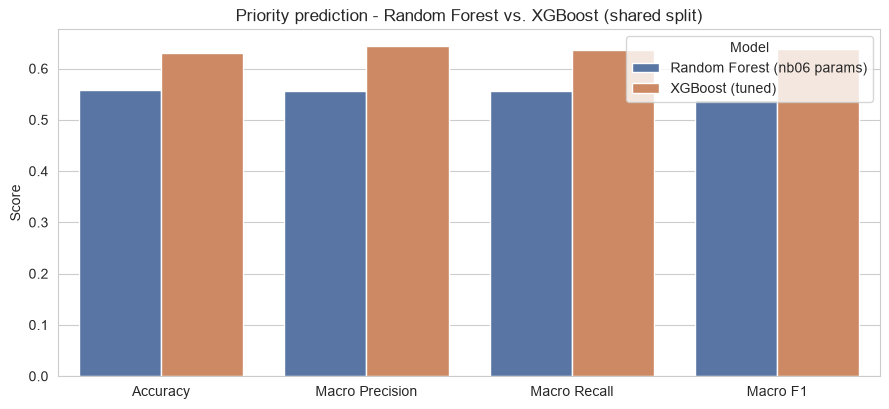

In [11]:
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
plot_df = comparison.melt(id_vars="Model", value_vars=metrics,
                          var_name="Metric", value_name="Score")
plt.figure(figsize=(9, 4.2))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="deep")
plt.title("Priority prediction - Random Forest vs. XGBoost (shared split)")
plt.ylabel("Score"); plt.xlabel("")
plt.tight_layout()
plt.show()

In [12]:
joblib.dump(best_xgb, f"{MODELS}/priority_xgb_model.joblib")
comparison.to_csv(f"{MODELS}/week3_priority_comparison.csv", index=False)
print("Saved priority_xgb_model.joblib and week3_priority_comparison.csv")

Saved priority_xgb_model.joblib and week3_priority_comparison.csv


## 6. Conclusions & Week 4 Recommendation

- Both models were evaluated on the **identical feature matrix and shared stratified split** (saved to `models/` for reuse).
- `days_to_deadline` dominates feature importance for both models — confirming the Week 1 EDA finding — followed by `estimated_hours` and the Bug Fix/Deployment category signals.
- Priority is intrinsically noisier than category (it was generated from deadline/effort with random variation plus 5% label noise), so scores sit well below the Week 2 category-classification results — expected, not a defect.
- See the printed comparison above and `reports/week3_priority_comparison.md` for the final recommendation carried into Week 4.